# L-NODEC: Double Integrator Example

This notebook demonstrates L-NODEC and compares it with NODEC baseline.

**Problem (Set-to-Point Stabilization):**
- Dynamics: $\dot{x}_1 = x_2$, $\dot{x}_2 = u$
- Control bounds: $u \in [-10, 10]$
- Target state: $z = (1, 0)$

**Experimental Design:**
- **Training:** All methods train on $x_0 \sim \mathcal{N}(0, 0.05)$ (realistic perturbations)
- **Evaluation:** Test on $x_0 \sim \text{Uniform}([-0.1, 0.1])$ (robustness at $\pm 2\sigma$ edge cases)

**Methods Compared:**
1. **L-NODEC**: Lyapunov loss with exponential stability guarantees
2. **L-NODEC-Constrained**: With velocity constraint $x_2 \leq 2.0$ m/s 
3. **NODEC-Terminal**: Terminal cost $(x(T)-z)^T P (x(T)-z)$

## Setup

**Note:** This notebook supports two workflows:

1. **First run:** Set `load_from_saved = False` to train from scratch (saves to `trained_policy_double_integrator.pt`)
2. **Plot adjustments:** Set `load_from_saved = True` to load trained policy and skip training
   - Modify `visualization.py` 
   - Just re-run the plotting cells (no kernel restart needed!)
   - Auto-reload is enabled via `%autoreload 2`

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
#import torch_optimizer as optim_extra  # RAdam optimizer

from policy import NeuralPolicy
from lyapunov import QuadraticLyapunov
from loss import LyapunovLoss
from simulator import Simulator
from trainer import LNODECTrainer
from systems import double_integrator_dynamics
from samplers import NormalSetToPointSampler, SetToPointSampler  # Normal for training, Uniform for eval
from visualization import (
    plot_phase_portrait, 
    plot_state_trajectories, 
    plot_controls, 
    plot_lyapunov_decay,
    plot_stability_violation,
    plot_exponential_stability_check,
    set_plot_style,
)

# Apply publication-quality plotting style
set_plot_style()

# Auto-reload visualization module when it changes
%load_ext autoreload
%autoreload 2

%matplotlib inline

print("Modules loaded. Auto-reload enabled for visualization.py")

Modules loaded. Auto-reload enabled for visualization.py


## Configuration

In [2]:
# Device and dtype
device = torch.device("cpu")
dtype = torch.float64  # Use float64 for better numerical precision (matches OLD code)

# Set random seed for reproducibility and fair comparison
torch.manual_seed(100)
np.random.seed(100)

# System parameters
state_dim = 2  # [position, velocity]
control_dim = 1  # [acceleration]
u_min = -10.0
u_max = 10.0

# Set-to-Point Stabilization with Realistic Perturbations:
# TRAINING: x0 ~ Normal(mean=0, std=0.05) - realistic perturbations
# EVALUATION: x0 ~ Uniform([-0.1, 0.1]) - test robustness at ±2σ edge cases
x0_mean = torch.tensor([0.0, 0.0], dtype=dtype, device=device)
x0_std = torch.tensor([0.05, 0.0], dtype=dtype, device=device)
z_target = torch.tensor([1.0, 0.0], dtype=dtype, device=device)  # FIXED target!

# For evaluation (robustness test at ±2σ)
x0_eval_min = torch.tensor([-0.1, 0.0], dtype=dtype, device=device)
x0_eval_max = torch.tensor([0.1, 0.0], dtype=dtype, device=device)

# Time discretization
t_final = 1.5
num_steps = 1000
time_grid = torch.linspace(0, t_final, num_steps, dtype=dtype, device=device)

# Training hyperparameters (based on OLD working code)
num_epochs = 300
batch_size = 4
learning_rate = 0.005
kappa = 10.0

# Lyapunov/Cost matrix P
P_diag = [1.0, 1e-4] 
P = torch.diag(torch.tensor(P_diag, dtype=dtype, device=device))

print("Configuration")
print(f"  dtype: {dtype} (better precision)")
print(f"  State dim: {state_dim}, Control dim: {control_dim}")
print(f"  Control bounds: [{u_min}, {u_max}]")
print(f"  Time horizon: [0, {t_final}] with {num_steps} steps")
print(f"\nTraining Distribution:")
print(f"  x0 ~ Normal(mean={x0_mean[0].item()}, std={x0_std[0].item()}) × {{0}}")
print(f"  Target z (FIXED): {z_target.numpy()}")
print(f"\nEvaluation (Robustness Test):")
print(f"  x0 ~ Uniform([{x0_eval_min[0].item()}, {x0_eval_max[0].item()}]) × {{0}} (±2σ)")
print(f"\nCost/Lyapunov matrix P:\n{P}")
print(f"  P diagonal: {P_diag} (tiny velocity weight - Lyapunov handles coupling!)")
print(f"  κ (kappa): {kappa} (OLD working value, not 10.0!)")
print(f"  Learning rate: {learning_rate} (matches OLD code)")
print(f"  Batch size: {batch_size}")
print(f"  Epochs: {num_epochs}")

Configuration
  dtype: torch.float64 (better precision)
  State dim: 2, Control dim: 1
  Control bounds: [-10.0, 10.0]
  Time horizon: [0, 1.5] with 1000 steps

Training Distribution:
  x0 ~ Normal(mean=0.0, std=0.05) × {0}
  Target z (FIXED): [1. 0.]

Evaluation (Robustness Test):
  x0 ~ Uniform([-0.1, 0.1]) × {0} (±2σ)

Cost/Lyapunov matrix P:
tensor([[1.0000e+00, 0.0000e+00],
        [0.0000e+00, 1.0000e-04]], dtype=torch.float64)
  P diagonal: [1.0, 0.0001] (tiny velocity weight - Lyapunov handles coupling!)
  κ (kappa): 10.0 (OLD working value, not 10.0!)
  Learning rate: 0.005 (matches OLD code)
  Batch size: 4
  Epochs: 300


## Create Components

In [3]:
# IMPORTANT: Set seed before creating policy for fair comparison
torch.manual_seed(100)

# 1. Neural Policy (for L-NODEC)
policy = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32],  # Match paper: 3-4 hidden layers of 32 nodes
    u_min=u_min,
    u_max=u_max,
).to(device=device, dtype=dtype)

print(f"Policy: {sum(p.numel() for p in policy.parameters())} parameters")

# 2. Lyapunov function
lyapunov_fn = QuadraticLyapunov(P)

# 3. Lyapunov loss
lyapunov_loss = LyapunovLoss(lyapunov_fn, kappa=kappa)

# 4. Simulator (shared by all methods)
simulator = Simulator(
    dynamics_fn=double_integrator_dynamics,
    method="rk4",  # Euler is sufficient for double integrator
    rtol=1e-6,
    atol=1e-8,
)

# 5. Dataset sampler for TRAINING - Normal distribution (realistic perturbations)
# All methods use this same sampler for fair comparison
dataset_sampler_train = NormalSetToPointSampler(
    x0_mean=x0_mean,
    x0_std=x0_std,
    x_target=z_target,  
    device=device,
    dtype=dtype,
)

# 6. Dataset sampler for evaluation - Uniform distribution (robustness test at ±2σ)
dataset_sampler_eval = SetToPointSampler(
    x0_min=x0_eval_min,
    x0_max=x0_eval_max,
    x_target=z_target,  
    device=device,
    dtype=dtype,
)

# 7. Optimizer - RAdam for robust adaptive learning
# optimizer = optim_extra.RAdam(
#     policy.parameters(), 
#     lr=learning_rate,
#     betas=(0.9, 0.999),
#     weight_decay=1e-4,
# )

optimizer = torch.optim.RMSprop(
    policy.parameters(),
    lr=learning_rate,
    alpha=0.99,
    eps=1e-8,
    weight_decay=1e-4,
)

# 8. Trainer (L-NODEC)
trainer = LNODECTrainer(
    policy=policy,
    dynamics_fn=double_integrator_dynamics,
    lyapunov_loss=lyapunov_loss,
    simulator=simulator,
    optimizer=optimizer,
    dataset_sampler=dataset_sampler_train,  # Train with Normal distribution
)

print("\nComponents created successfully!")
print(f"Training sampler: Normal(μ={x0_mean[0].item()}, σ={x0_std[0].item()})")
print(f"Evaluation sampler: Uniform([{x0_eval_min[0].item()}, {x0_eval_max[0].item()}])")
print(f"Target z: {z_target.numpy()}")

Policy: 1185 parameters

Components created successfully!
Training sampler: Normal(μ=0.0, σ=0.05)
Evaluation sampler: Uniform([-0.1, 0.1])
Target z: [1. 0.]


## Train Policy

In [4]:
load_from_saved = False# Set to False to retrain

In [5]:
import os

# Path to save/load training results
SAVE_PATH = f"results_doubleint_lnodec_unconstrained_kappa{int(kappa)}.pt"

if load_from_saved and os.path.exists(SAVE_PATH):
    print(f"Loading trained policy from {SAVE_PATH}...")
    checkpoint = torch.load(SAVE_PATH)
    policy.load_state_dict(checkpoint['policy_state_dict'])
    history = checkpoint['history']
    print(f"Loaded! Training was done for {len(history['loss'])} epochs.")
    print(f"Final loss: {history['loss'][-1]:.4e}")
    print(f"Final V_decay: {history['V_decay'][-1]:.4f}")
else:
    print("Training policy from scratch...\n")
    history = trainer.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=10,
        verbose=True,
    )
    
    # Save trained policy and history
    torch.save({
        'policy_state_dict': policy.state_dict(),
        'history': history,
        'hyperparameters': {
            'num_epochs': num_epochs,
            'batch_size': batch_size,
            'learning_rate': learning_rate,
            'kappa': kappa,
            'P_diag': P_diag,
            't_final': t_final,
            'num_steps': num_steps,
        }
    }, SAVE_PATH)
    print(f"\nTraining complete! Saved to {SAVE_PATH}")

Training policy from scratch...

Epoch    0/300: Loss=9.5769e+03, Final Dist=0.9802, V_decay=1.0143
Epoch   10/300: Loss=3.0897e+03, Final Dist=1.3935, V_decay=0.0889
Epoch   20/300: Loss=2.8901e+03, Final Dist=1.0588, V_decay=0.0561
Epoch   30/300: Loss=1.3309e+03, Final Dist=0.1237, V_decay=0.0094
Epoch   40/300: Loss=1.2560e+03, Final Dist=0.3293, V_decay=0.0000
Epoch   50/300: Loss=1.2707e+03, Final Dist=0.1925, V_decay=0.0024
Epoch   60/300: Loss=1.1500e+03, Final Dist=0.1312, V_decay=0.0020
Epoch   70/300: Loss=1.2025e+03, Final Dist=0.1091, V_decay=0.0016
Epoch   80/300: Loss=1.0714e+03, Final Dist=0.0750, V_decay=0.0015
Epoch   90/300: Loss=1.1728e+03, Final Dist=0.0810, V_decay=0.0004
Epoch  100/300: Loss=1.1899e+03, Final Dist=0.0666, V_decay=0.0013
Epoch  110/300: Loss=1.0627e+03, Final Dist=0.0550, V_decay=0.0012
Epoch  120/300: Loss=1.1329e+03, Final Dist=0.0516, V_decay=0.0011
Epoch  130/300: Loss=1.1105e+03, Final Dist=0.0408, V_decay=0.0001
Epoch  140/300: Loss=1.0943e+

## Train NODEC Baselines for Comparison

In [6]:
from cost import TerminalCost
from nodec_trainer import NODECTrainer
import os

SAVE_PATH_TERMINAL = "results_doubleint_nodec_terminal.pt"

print("="*60)
print("NODEC-Terminal: Terminal cost (x(T)-z)ᵀP(x(T)-z)")
print("="*60)

torch.manual_seed(100)

policy_terminal = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32, 32],
    u_min=u_min,
    u_max=u_max,
).to(device=device, dtype=dtype)

terminal_cost = TerminalCost(P_phi=P)

optimizer_terminal = torch.optim.RMSprop(
    policy_terminal.parameters(),
    lr=0.02,  # 2x higher for terminal cost (sparse gradients)
    alpha=0.99,
    eps=1e-8,
    weight_decay=1e-4,
)

trainer_terminal = NODECTrainer(
    policy=policy_terminal,
    dynamics_fn=double_integrator_dynamics,
    cost_fn=terminal_cost,
    simulator=simulator,
    optimizer=optimizer_terminal,
    dataset_sampler=dataset_sampler_train,
)

if load_from_saved and os.path.exists(SAVE_PATH_TERMINAL):
    checkpoint = torch.load(SAVE_PATH_TERMINAL)
    policy_terminal.load_state_dict(checkpoint['policy_state_dict'])
    history_terminal = checkpoint['history']
    print(f"Loaded! Final loss: {history_terminal['loss'][-1]:.4e}")
else:
    print("Training with RMSprop ...\n")
    history_terminal = trainer_terminal.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=20,
        verbose=True,
    )
    torch.save({'policy_state_dict': policy_terminal.state_dict(), 'history': history_terminal}, SAVE_PATH_TERMINAL)

print(f"Final distance: {history_terminal['final_distance'][-1]:.4f}\n")
print("✓ NODEC-Terminal trained with RMSprop (lr=0.02 for sparse terminal gradients)")

NODEC-Terminal: Terminal cost (x(T)-z)ᵀP(x(T)-z)
Training with RMSprop ...

Epoch    0/300: Loss=1.0025e+00, Final Dist=1.0012
Epoch   20/300: Loss=9.0219e-04, Final Dist=0.3407
Epoch   40/300: Loss=1.6576e-04, Final Dist=0.3410
Epoch   60/300: Loss=2.1698e-04, Final Dist=0.3362
Epoch   80/300: Loss=1.4226e-04, Final Dist=0.3285
Epoch  100/300: Loss=1.4294e-04, Final Dist=0.3296
Epoch  120/300: Loss=3.7371e-05, Final Dist=0.3155
Epoch  140/300: Loss=3.1065e-05, Final Dist=0.3175
Epoch  160/300: Loss=5.6797e-05, Final Dist=0.3113
Epoch  180/300: Loss=2.3615e-05, Final Dist=0.2915
Epoch  200/300: Loss=3.7800e-03, Final Dist=0.3190
Epoch  220/300: Loss=7.2284e-04, Final Dist=0.2777
Epoch  240/300: Loss=1.4229e-04, Final Dist=0.2629
Epoch  260/300: Loss=4.1580e-03, Final Dist=0.2429
Epoch  280/300: Loss=1.0746e-03, Final Dist=0.2602
Epoch  299/300: Loss=2.9423e-03, Final Dist=0.2599
Final distance: 0.2599

✓ NODEC-Terminal trained with RMSprop (lr=0.02 for sparse terminal gradients)


In [7]:
from constraints import ConstraintHandler
import os

SAVE_PATH_CONSTRAINED = f"results_doubleint_lnodec_constrained_kappa{int(kappa)}.pt"

# Velocity constraint: x₂ ≤ 2.0
x2_max = 2.0    

def velocity_constraint(x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
    """g(x,u) = x₂ - x₂_max ≤ 0"""
    x2 = x[..., 1] if x.ndim > 0 else x[1]
    return x2 - x2_max

# Create constraint handler with smooth penalty
# Uses: P(g) = β · [τ · softplus(g/τ)]²
constraint_handler = ConstraintHandler(
    constraint_fns=[velocity_constraint],
    beta=5.0,     # Penalty weight (from paper/OLDER implementation)
    tau=0.01,      # Temperature for smooth max (smaller = sharper)
)

print("="*60)
print(f"L-NODEC-Constrained: x₂ ≤ {x2_max} m/s")
print("="*60)
print(f"Constraint method: Smooth penalty P(g) = β·[τ·softplus(g/τ)]²")
print(f"  β (beta): {constraint_handler.beta} (penalty strength)")
print(f"  τ (tau):  {constraint_handler.tau} (smoothness, smaller=sharper)")

# Same seed for fair comparison
torch.manual_seed(100)

policy_constrained = NeuralPolicy(
    state_dim=state_dim,
    control_dim=control_dim,
    hidden_dims=[32, 32, 32],
    u_min=u_min,
    u_max=u_max,
).to(device=device, dtype=dtype)

lyapunov_loss_constrained = LyapunovLoss(
    lyapunov_fn=lyapunov_fn,  # Same Lyapunov function
    kappa=kappa,
    constraint_handler=constraint_handler,  # Add constraints!
)

optimizer_constrained = torch.optim.RMSprop(
    policy_constrained.parameters(),
    lr=learning_rate,
    alpha=0.99,
    eps=1e-8,
    weight_decay=1e-4,
)

trainer_constrained = LNODECTrainer(
    policy=policy_constrained,
    dynamics_fn=double_integrator_dynamics,
    lyapunov_loss=lyapunov_loss_constrained,
    simulator=simulator,
    optimizer=optimizer_constrained,
    dataset_sampler=dataset_sampler_train,
)

if load_from_saved and os.path.exists(SAVE_PATH_CONSTRAINED):
    checkpoint = torch.load(SAVE_PATH_CONSTRAINED)
    policy_constrained.load_state_dict(checkpoint['policy_state_dict'])
    history_constrained = checkpoint['history']
    print(f"Loaded! Final loss: {history_constrained['loss'][-1]:.4e}")
else:
    print("\nTraining with smooth penalty...\n")
    history_constrained = trainer_constrained.train(
        num_epochs=num_epochs,
        time_grid=time_grid,
        batch_size=batch_size,
        log_interval=20,
        verbose=True,
    )
    
    torch.save({
        'policy_state_dict': policy_constrained.state_dict(),
        'history': history_constrained,
    }, SAVE_PATH_CONSTRAINED)

print(f"\nFinal distance: {history_constrained['final_distance'][-1]:.4f}")
print("✓ L-NODEC-Constrained trained with smooth penalty!")

L-NODEC-Constrained: x₂ ≤ 2.0 m/s
Constraint method: Smooth penalty P(g) = β·[τ·softplus(g/τ)]²
  β (beta): 5.0 (penalty strength)
  τ (tau):  0.01 (smoothness, smaller=sharper)

Training with smooth penalty...

Epoch    0/300: Loss=9.9880e+02, Final Dist=1.0012, V_decay=1.0073
Epoch   20/300: Loss=1.7202e+02, Final Dist=0.5945, V_decay=0.3821
Epoch   40/300: Loss=1.8182e+01, Final Dist=0.3821, V_decay=0.1132
Epoch   60/300: Loss=1.6710e+01, Final Dist=0.3715, V_decay=0.1121
Epoch   80/300: Loss=1.6253e+01, Final Dist=0.3672, V_decay=0.1116
Epoch  100/300: Loss=1.7336e+01, Final Dist=0.3697, V_decay=0.1066
Epoch  120/300: Loss=1.6603e+01, Final Dist=0.3641, V_decay=0.1064
Epoch  140/300: Loss=1.7942e+01, Final Dist=0.3687, V_decay=0.1021
Epoch  160/300: Loss=1.7857e+01, Final Dist=0.3659, V_decay=0.1008
Epoch  180/300: Loss=1.5950e+01, Final Dist=0.3542, V_decay=0.1026
Epoch  200/300: Loss=1.6980e+01, Final Dist=0.3567, V_decay=0.0986
Epoch  220/300: Loss=1.6439e+01, Final Dist=0.3511,

In [8]:
# from constraints import ConstraintHandler
# import os

# SAVE_PATH_CONSTRAINED = "trained_policy_lnodec_constrained.pt"

# # Velocity constraint: x₂ ≤ 2.5
# x2_max = 2.5

# def velocity_constraint(x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
#     """g(x,u) = x₂ - x₂_max ≤ 0"""
#     x2 = x[..., 1] if x.ndim > 0 else x[1]
#     return x2 - x2_max

# # Create constraint handler with relaxed log barrier
# constraint_handler = ConstraintHandler(
#     constraint_fns=[velocity_constraint],
#     alpha=2.0,   # Penalty weight
#     delta=0.1,   # Relaxation parameter
# )

# print("="*60)
# print(f"L-NODEC-Constrained: x₂ ≤ {x2_max} m/s")
# print("="*60)
# print(f"Constraint method: Relaxed logarithmic barrier")
# print(f"Penalty α: {constraint_handler.alpha}")
# print(f"Relaxation δ: {constraint_handler.barriers[0].delta}")

# # Same seed for fair comparison
# torch.manual_seed(42)

# policy_constrained = NeuralPolicy(
#     state_dim=state_dim,
#     control_dim=control_dim,
#     hidden_dims=[32, 32, 32, 32],
#     u_min=u_min,
#     u_max=u_max,
# ).to(device=device, dtype=dtype)

# lyapunov_loss_constrained = LyapunovLoss(
#     lyapunov_fn=lyapunov_fn,  # Same Lyapunov function
#     kappa=kappa,
#     constraint_handler=constraint_handler,  # Add constraints!
# )

# # RAdam optimizer for constrained L-NODEC
# # optimizer_constrained = optim_extra.RAdam(
# #     policy_constrained.parameters(), 
# #     lr=learning_rate,  # Same 0.01
# #     betas=(0.9, 0.999),
# #     weight_decay=1e-4,
# # )

# optimizer_constrained = torch.optim.RMSprop(
#     policy_constrained.parameters(),
#     lr=learning_rate,
#     alpha=0.99,
#     eps=1e-8,
#     weight_decay=1e-4,
# )

# trainer_constrained = LNODECTrainer(
#     policy=policy_constrained,
#     dynamics_fn=double_integrator_dynamics,
#     lyapunov_loss=lyapunov_loss_constrained,
#     simulator=simulator,
#     optimizer=optimizer_constrained,
#     dataset_sampler=dataset_sampler_train,
# )

# if load_from_saved and os.path.exists(SAVE_PATH_CONSTRAINED):
#     checkpoint = torch.load(SAVE_PATH_CONSTRAINED)
#     policy_constrained.load_state_dict(checkpoint['policy_state_dict'])
#     history_constrained = checkpoint['history']
#     print(f"Loaded! Final loss: {history_constrained['loss'][-1]:.4e}")
# else:
#     print("Training while imposing state constraint...\n")
#     history_constrained = trainer_constrained.train(
#         num_epochs=num_epochs,
#         time_grid=time_grid,
#         batch_size=batch_size,
#         log_interval=50,
#         verbose=True,
#     )
    
#     torch.save({
#         'policy_state_dict': policy_constrained.state_dict(),
#         'history': history_constrained,
#     }, SAVE_PATH_CONSTRAINED)

# print(f"Final distance: {history_constrained['final_distance'][-1]:.4f}\n")
# print("✓ L-NODEC-Constrained trained!")

In [9]:
# from cost import StageCost, TerminalCost
# from nodec_trainer import NODECTrainer
# import os

# # Save paths for baselines
# SAVE_PATH_STAGE = "trained_policy_nodec_stage.pt"
# SAVE_PATH_TERMINAL = "trained_policy_nodec_terminal.pt"

# # ===== NODEC-Stage Baseline =====
# print("="*60)
# print("NODEC-Stage: Stage cost Σ(x-z)ᵀQ(x-z) (Q=P)")
# print("="*60)

# # IMPORTANT: Use SAME random seed as L-NODEC for fair initialization
# torch.manual_seed(42)

# policy_stage = NeuralPolicy(
#     state_dim=state_dim,
#     control_dim=control_dim,
#     hidden_dims=[32, 32, 32, 32],
#     u_min=u_min,
#     u_max=u_max,
# ).to(device=device, dtype=dtype)

# stage_cost = StageCost(Q=P, R=None)  # Removed integration_method - just sums!
# optimizer_stage = torch.optim.Adam(policy_stage.parameters(), lr=learning_rate)

# trainer_stage = NODECTrainer(
#     policy=policy_stage,
#     dynamics_fn=double_integrator_dynamics,
#     cost_fn=stage_cost,
#     simulator=simulator,
#     optimizer=optimizer_stage,
#     dataset_sampler=dataset_sampler_train,  # Same Normal sampler as L-NODEC!
# )

# if load_from_saved and os.path.exists(SAVE_PATH_STAGE):
#     checkpoint = torch.load(SAVE_PATH_STAGE)
#     policy_stage.load_state_dict(checkpoint['policy_state_dict'])
#     history_stage = checkpoint['history']
#     print(f"Loaded! Final loss: {history_stage['loss'][-1]:.4e}")
# else:
#     print("Training with Normal(μ=0, σ=0.05) distribution...\n")
#     history_stage = trainer_stage.train(
#         num_epochs=num_epochs,
#         time_grid=time_grid,
#         batch_size=batch_size,
#         log_interval=50,
#         verbose=True,
#     )
#     torch.save({'policy_state_dict': policy_stage.state_dict(), 'history': history_stage}, SAVE_PATH_STAGE)

# print(f"Final distance: {history_stage['final_distance'][-1]:.4f}\n")

# # ===== NODEC-Terminal Baseline =====
# print("="*60)
# print("NODEC-Terminal: Terminal cost (x(T)-z)ᵀP(x(T)-z)")
# print("="*60)

# # IMPORTANT: Use SAME random seed as L-NODEC for fair initialization
# torch.manual_seed(42)

# policy_terminal = NeuralPolicy(
#     state_dim=state_dim,
#     control_dim=control_dim,
#     hidden_dims=[32, 32, 32, 32],
#     u_min=u_min,
#     u_max=u_max,
# ).to(device=device, dtype=dtype)

# terminal_cost = TerminalCost(P_phi=P)
# optimizer_terminal = torch.optim.Adam(policy_terminal.parameters(), lr=learning_rate)

# trainer_terminal = NODECTrainer(
#     policy=policy_terminal,
#     dynamics_fn=double_integrator_dynamics,
#     cost_fn=terminal_cost,
#     simulator=simulator,
#     optimizer=optimizer_terminal,
#     dataset_sampler=dataset_sampler_train,  # Same Normal sampler as L-NODEC!
# )

# if load_from_saved and os.path.exists(SAVE_PATH_TERMINAL):
#     checkpoint = torch.load(SAVE_PATH_TERMINAL)
#     policy_terminal.load_state_dict(checkpoint['policy_state_dict'])
#     history_terminal = checkpoint['history']
#     print(f"Loaded! Final loss: {history_terminal['loss'][-1]:.4e}")
# else:
#     print("Training with Normal(μ=0, σ=0.05) distribution...\n")
#     history_terminal = trainer_terminal.train(
#         num_epochs=num_epochs,
#         time_grid=time_grid,
#         batch_size=batch_size,
#         log_interval=50,
#         verbose=True,
#     )
#     torch.save({'policy_state_dict': policy_terminal.state_dict(), 'history': history_terminal}, SAVE_PATH_TERMINAL)

# print(f"Final distance: {history_terminal['final_distance'][-1]:.4f}\n")

# print("✓ All methods trained with:")
# print("  - Same initialization (seed=42)")
# print("  - Same training distribution: Normal(μ=0, σ=0.05)")
# print("  - Same architecture, learning rate, epochs")
# print("  - Loss = sum of pointwise costs (no integration weights)")

### Plotting

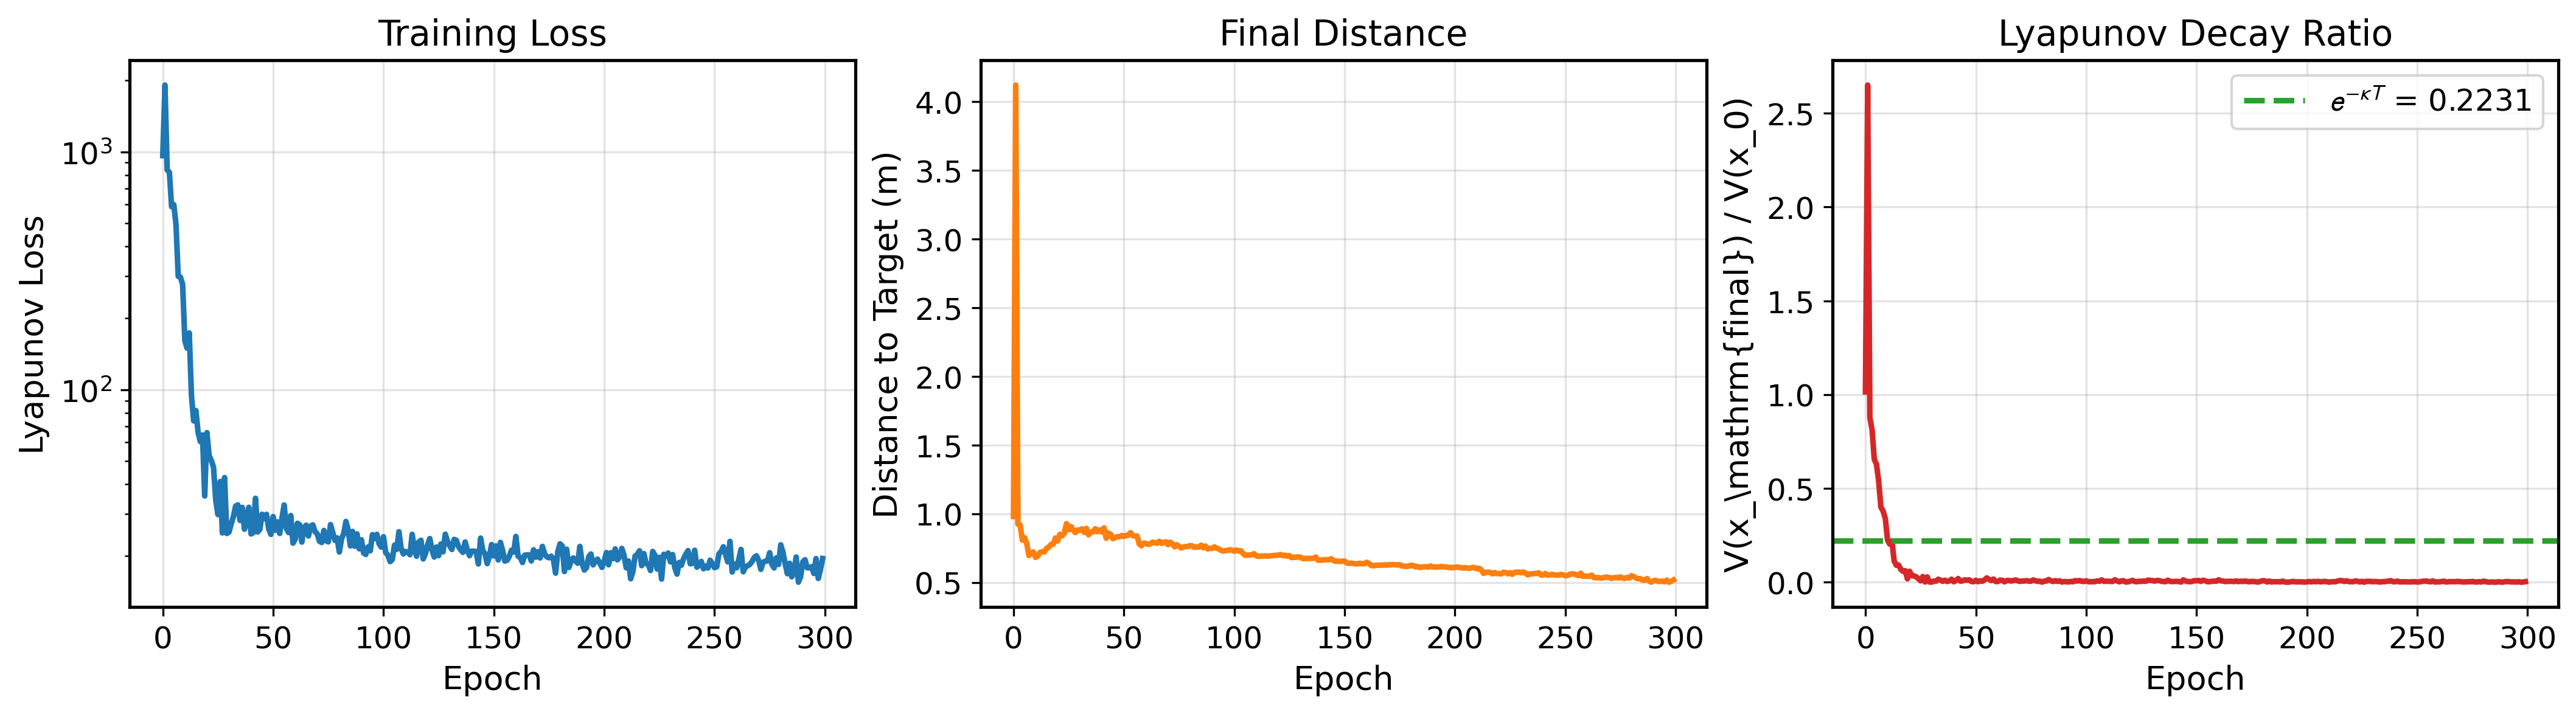

In [10]:
# (Optional) if you haven't already:
# set_plot_style()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

# Loss over epochs (blue)
axes[0].plot(history['loss'], linewidth=2.2, color='C0')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Lyapunov Loss')
axes[0].set_title('Training Loss')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.35)

# Final distance over epochs (orange)
axes[1].plot(history['final_distance'], linewidth=2.2, color='C1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Distance to Target (m)')
axes[1].set_title('Final Distance')
axes[1].grid(True, alpha=0.35)

# V decay ratio over epochs (red) + exp bound (green)
axes[2].plot(history['V_decay'], linewidth=2.2, color='C3')
expT = np.exp(-kappa * t_final)
axes[2].axhline(expT, color='C2', linestyle='--', linewidth=2.2,
                label=fr'$e^{{-\kappa T}}$ = {expT:.4f}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('V(x_\mathrm{final}) / V(x_0)')
axes[2].set_title('Lyapunov Decay Ratio')
axes[2].legend()
axes[2].grid(True, alpha=0.35)

plt.show()


## Generate Adversarial Trajectories (Robustness Test)

Sample initial conditions uniformly from [-0.1, 0.1] (±2σ) to test robustness.  
These are edge cases that are rare in the training distribution.

In [11]:
# Number of robustness test trajectories
num_adversarial = 20  # Test at ±2σ edge cases

# Sample initial conditions UNIFORMLY from [-0.1, 0.1] (evaluation distribution)
# This tests robustness at edge cases (±2σ from training distribution)
x0_samples = []
for _ in range(num_adversarial):
    x0, z = dataset_sampler_eval()  # Uniform sampling for robustness test
    x0_samples.append(x0)

# Use the FIXED target for all evaluations
target_fixed = z_target

# Evaluate L-NODEC policy on all samples WITH stability metrics
trajectories = []
controls_list = []
V_trajectories = []
stability_violations = []
V_decay_trajectories = []
first_stable_times = []

print(f"Generating {num_adversarial} test trajectories with Uniform([-0.1, 0.1])...")
for x0 in x0_samples:
    results = trainer.evaluate(x0, target_fixed, time_grid, compute_stability_metrics=True)
    
    traj = results['trajectory'].cpu().numpy()
    ctrl = results['controls'].cpu().numpy()
    V_traj = results['V_trajectory'].cpu().numpy()
    stability_viol = results['stability_violation'].cpu().numpy()
    V_decay_traj = results['V_decay_trajectory'].cpu().numpy()
    
    trajectories.append(traj)
    controls_list.append(ctrl)
    V_trajectories.append(V_traj)
    stability_violations.append(stability_viol)
    V_decay_trajectories.append(V_decay_traj)
    first_stable_times.append(results['first_stable_time'])

initial_states = np.array([x0.cpu().numpy() for x0 in x0_samples])
final_states = np.array([traj[-1] for traj in trajectories])
target_state = target_fixed.cpu().numpy()
time_grid_np = time_grid.cpu().numpy()

print(f"Generated {num_adversarial} robustness test trajectories")
print(f"Initial states range: [{initial_states[:, 0].min():.3f}, {initial_states[:, 0].max():.3f}] (±2σ test)")
print(f"Final states range: [{final_states[:, 0].min():.3f}, {final_states[:, 0].max():.3f}]")
print(f"Target (FIXED): {target_state}")
print(f"\nStability achieved at (first trajectory): {first_stable_times[0]:.4f}s" if first_stable_times[0] else "\nStability NOT achieved")

Generating 20 test trajectories with Uniform([-0.1, 0.1])...
Generated 20 robustness test trajectories
Initial states range: [-0.092, 0.099] (±2σ test)
Final states range: [0.897, 1.014]
Target (FIXED): [1. 0.]

Stability achieved at (first trajectory): 0.0616s


## Exponential Stability Analysis

Visualize when exponential stability is achieved along each trajectory.

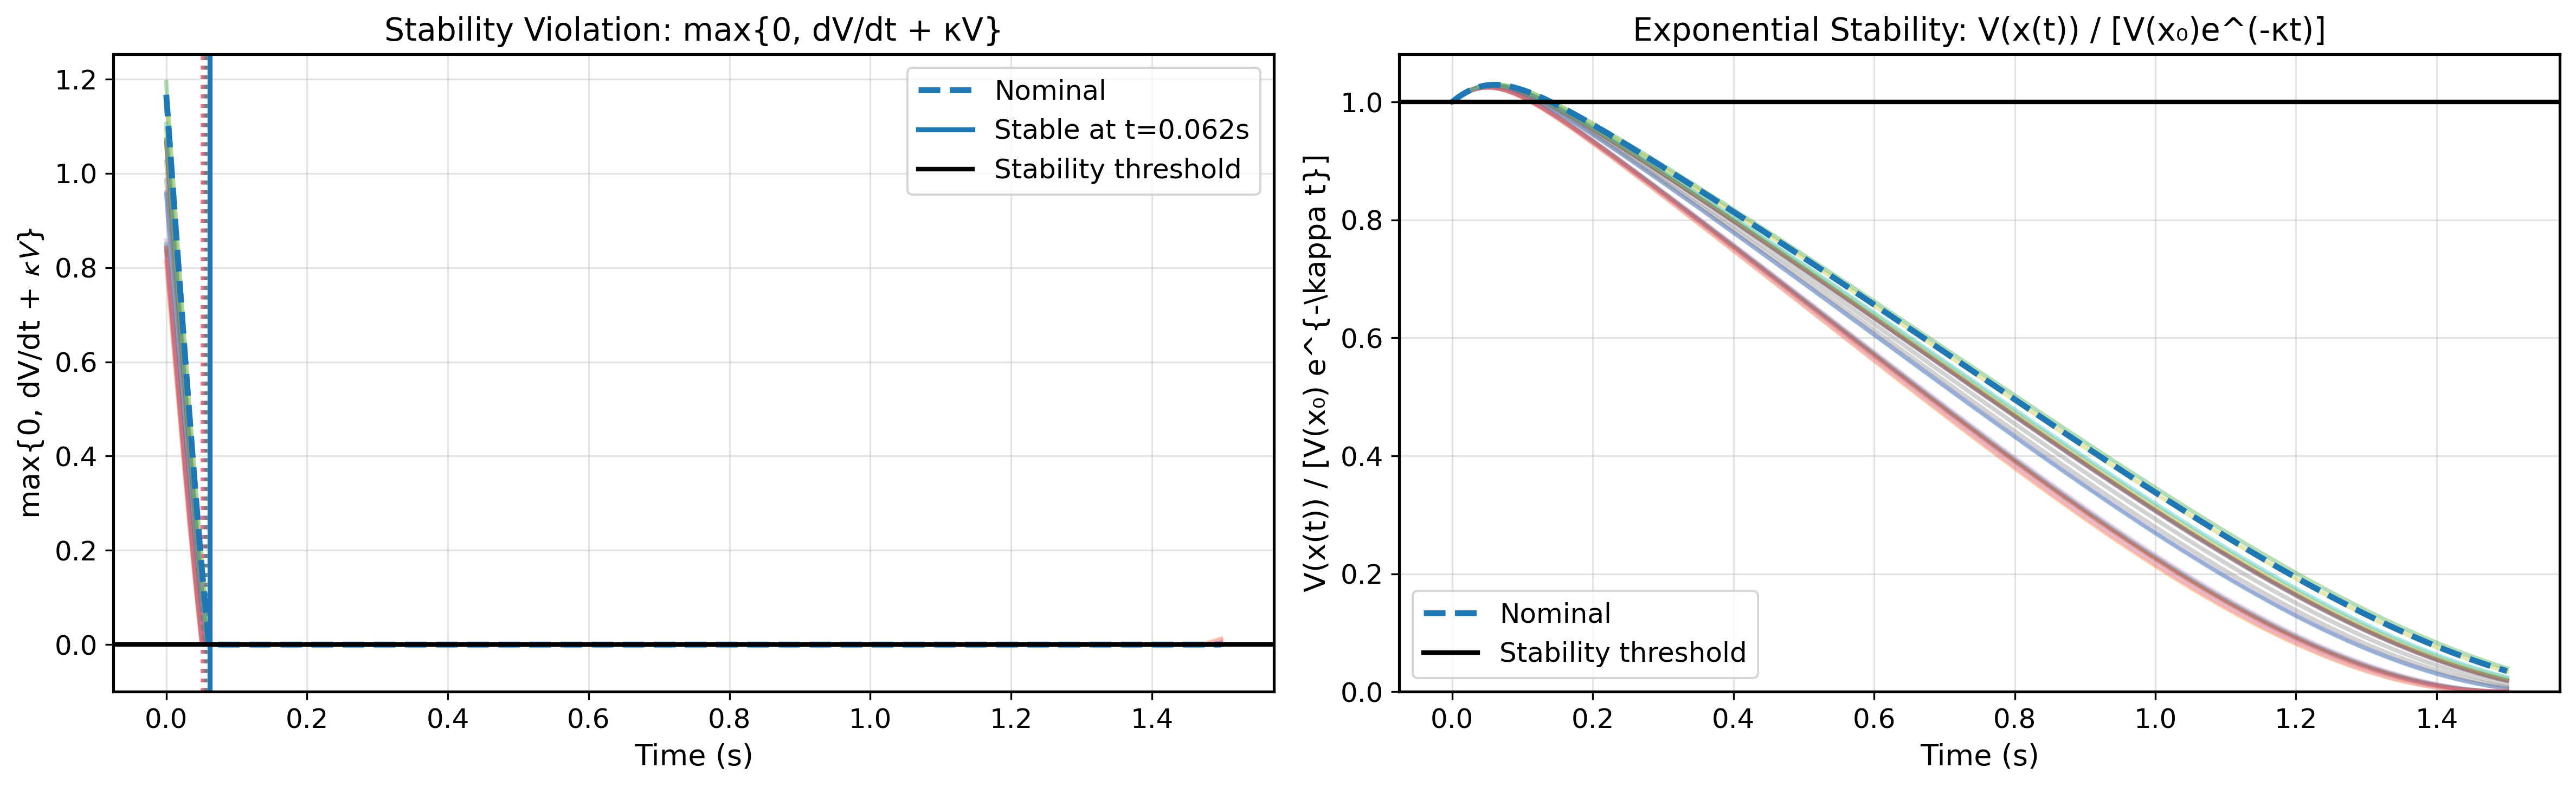


Stability Achievement Times
Trajectory 1: Stability achieved at t = 0.0616s
Trajectory 2: Stability achieved at t = 0.0526s
Trajectory 3: Stability achieved at t = 0.0616s
Trajectory 4: Stability achieved at t = 0.0586s
Trajectory 5: Stability achieved at t = 0.0556s
Trajectory 6: Stability achieved at t = 0.0511s
Trajectory 7: Stability achieved at t = 0.0526s
Trajectory 8: Stability achieved at t = 0.0571s
Trajectory 9: Stability achieved at t = 0.0616s
Trajectory 10: Stability achieved at t = 0.0526s
Trajectory 11: Stability achieved at t = 0.0556s
Trajectory 12: Stability achieved at t = 0.0511s
Trajectory 13: Stability achieved at t = 0.0586s
Trajectory 14: Stability achieved at t = 0.0526s
Trajectory 15: Stability achieved at t = 0.0586s
Trajectory 16: Stability achieved at t = 0.0586s
Trajectory 17: Stability achieved at t = 0.0511s
Trajectory 18: Stability achieved at t = 0.0556s
Trajectory 19: Stability achieved at t = 0.0601s
Trajectory 20: Stability achieved at t = 0.0601s


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Pointwise Lyapunov loss (when does max{0, dV/dt+κV} = 0?)
plot_stability_violation(
    axes[0],
    time_grid_np,
    stability_violations,
    first_stable_times,
    title="Stability Violation: max{0, dV/dt + κV}",
)

# Plot 2: Exponential stability check (is V(x(t)) ≤ V(x₀)e^(-κt)?)
plot_exponential_stability_check(
    axes[1],
    time_grid_np,
    V_decay_trajectories,
    title="Exponential Stability: V(x(t)) / [V(x₀)e^(-κt)]",
)

plt.tight_layout()
plt.show()

# Print when stability is achieved for each trajectory
print("\n" + "="*60)
print("Stability Achievement Times")
print("="*60)
for i, t_stable in enumerate(first_stable_times):
    if t_stable is not None:
        print(f"Trajectory {i+1}: Stability achieved at t = {t_stable:.4f}s")
    else:
        print(f"Trajectory {i+1}: Stability NOT achieved")
print("="*60)

## Generate Vector Field for Streamplot

In [13]:
def compute_vector_field(X1, X2):
    """Compute closed-loop vector field for streamplot"""
    U1 = np.zeros_like(X1)
    U2 = np.zeros_like(X2)
    
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            x = torch.tensor([X1[i, j], X2[i, j]], dtype=dtype, device=device)
            with torch.no_grad():
                u = policy(x)
                xdot = double_integrator_dynamics(x, u, 0.0)
            U1[i, j] = xdot[0].item()
            U2[i, j] = xdot[1].item()
    
    return U1, U2

## Phase Portrait

In [14]:
#re-import visualization module to apply changes
%load_ext autoreload
%autoreload 2
%matplotlib inline
print("Re-imported visualization module to apply changes.")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Re-imported visualization module to apply changes.


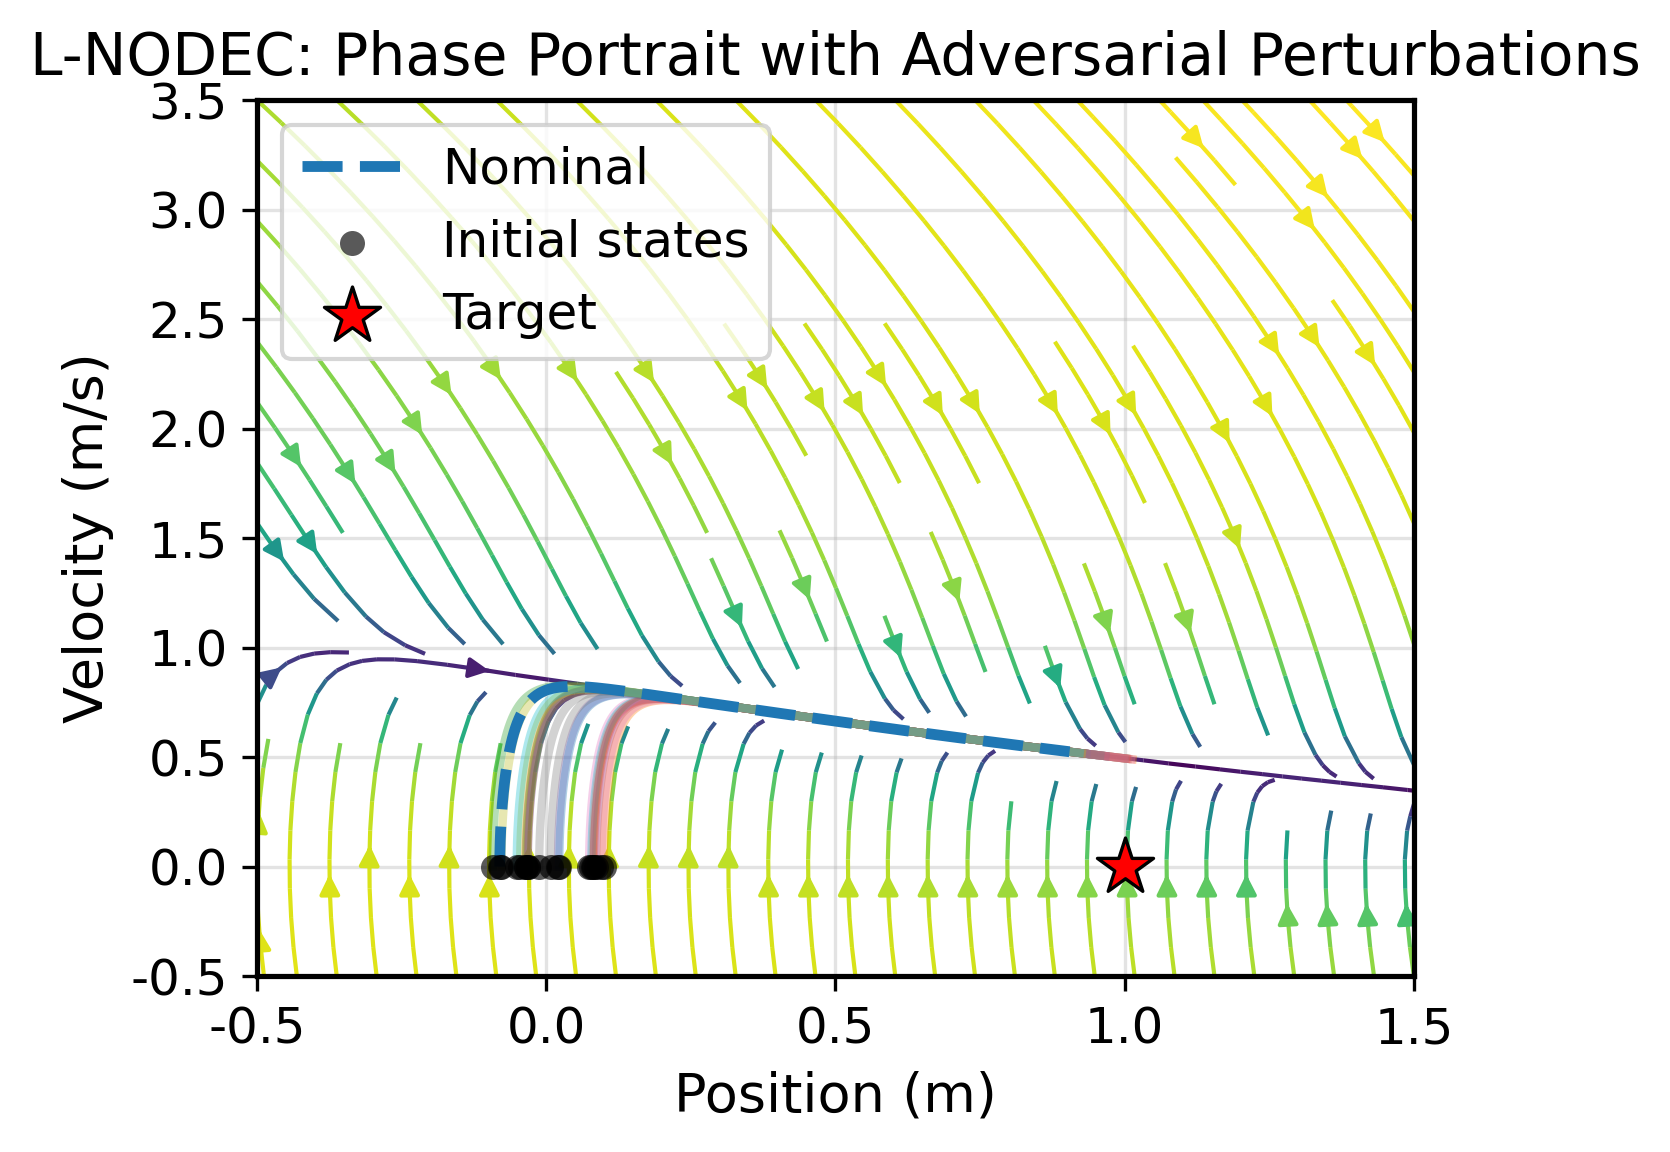

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

plot_phase_portrait(
    ax,
    trajectories=trajectories,
    initial_states=initial_states,
    final_states=final_states,
    target_state=target_state,
    vector_field_fn=compute_vector_field,
    title='L-NODEC: Phase Portrait with Adversarial Perturbations',
    x1_lim=(-0.5, 1.5),
    x2_lim=(-0.5, 3.5),
)

plt.tight_layout()
plt.show()

## Additional Plots

## Baseline Comparison: L-NODEC vs NODEC

Now that all methods are trained, let's compare them on the same test trajectory.

## Evaluate All Methods on Same Test IC

In [16]:
# Use first IC from adversarial set for comparison
x0_test = x0_samples[0]

print(f"Test IC: {x0_test.cpu().numpy()}")
print(f"Target: {z_target.numpy()}\n")

# Evaluate all THREE methods on the SAME initial condition
print("Evaluating all methods on same IC...")
result_lnodec = trainer.evaluate(x0_test, z_target, time_grid, compute_stability_metrics=False)
result_constrained = trainer_constrained.evaluate(x0_test, z_target, time_grid, compute_stability_metrics=False)
result_terminal = trainer_terminal.evaluate(x0_test, z_target, time_grid)

# Extract trajectories for plotting
traj_lnodec = result_lnodec['trajectory'].cpu().numpy()
traj_constrained = result_constrained['trajectory'].cpu().numpy()
traj_terminal = result_terminal['trajectory'].cpu().numpy()

# Extract controls
ctrl_lnodec = result_lnodec['controls'].cpu().numpy()
ctrl_constrained = result_constrained['controls'].cpu().numpy()
ctrl_terminal = result_terminal['controls'].cpu().numpy()

print("Final distances:")
print(f"  L-NODEC:             {result_lnodec['final_distance'].item():.4f} m")
print(f"  L-NODEC-Constrained: {result_constrained['final_distance'].item():.4f} m")
print(f"  NODEC-Terminal:      {result_terminal['final_distance'].item():.4f} m")

# Check constraint violations
print(f"\nVelocity constraint (x₂ ≤ {x2_max} m/s) violations:")
print(f"  L-NODEC:             max x₂ = {traj_lnodec[:, 1].max():.3f} m/s {'❌' if traj_lnodec[:, 1].max() > x2_max else '✅'}")
print(f"  L-NODEC-Constrained: max x₂ = {traj_constrained[:, 1].max():.3f} m/s {'❌' if traj_constrained[:, 1].max() > x2_max else '✅'}")
print(f"  NODEC-Terminal:      max x₂ = {traj_terminal[:, 1].max():.3f} m/s {'❌' if traj_terminal[:, 1].max() > x2_max else '✅'}")

Test IC: [-0.08018709  0.        ]
Target: [1. 0.]

Evaluating all methods on same IC...
Final distances:
  L-NODEC:             0.5332 m
  L-NODEC-Constrained: 0.3910 m
  NODEC-Terminal:      0.2450 m

Velocity constraint (x₂ ≤ 2.0 m/s) violations:
  L-NODEC:             max x₂ = 0.823 m/s ✅
  L-NODEC-Constrained: max x₂ = 0.980 m/s ✅
  NODEC-Terminal:      max x₂ = 1.446 m/s ✅


## Comparison Plot: Position & Lyapunov Decay

This plot compares:
- **Left:** Position trajectories for all methods
- **Right:** Lyapunov decay V(x(t))/V(x₀) for all methods (NODEC doesn't optimize for this!)

## Comparison Plot: All Methods

Compare position, velocity (with constraint), and Lyapunov decay for all 4 methods.

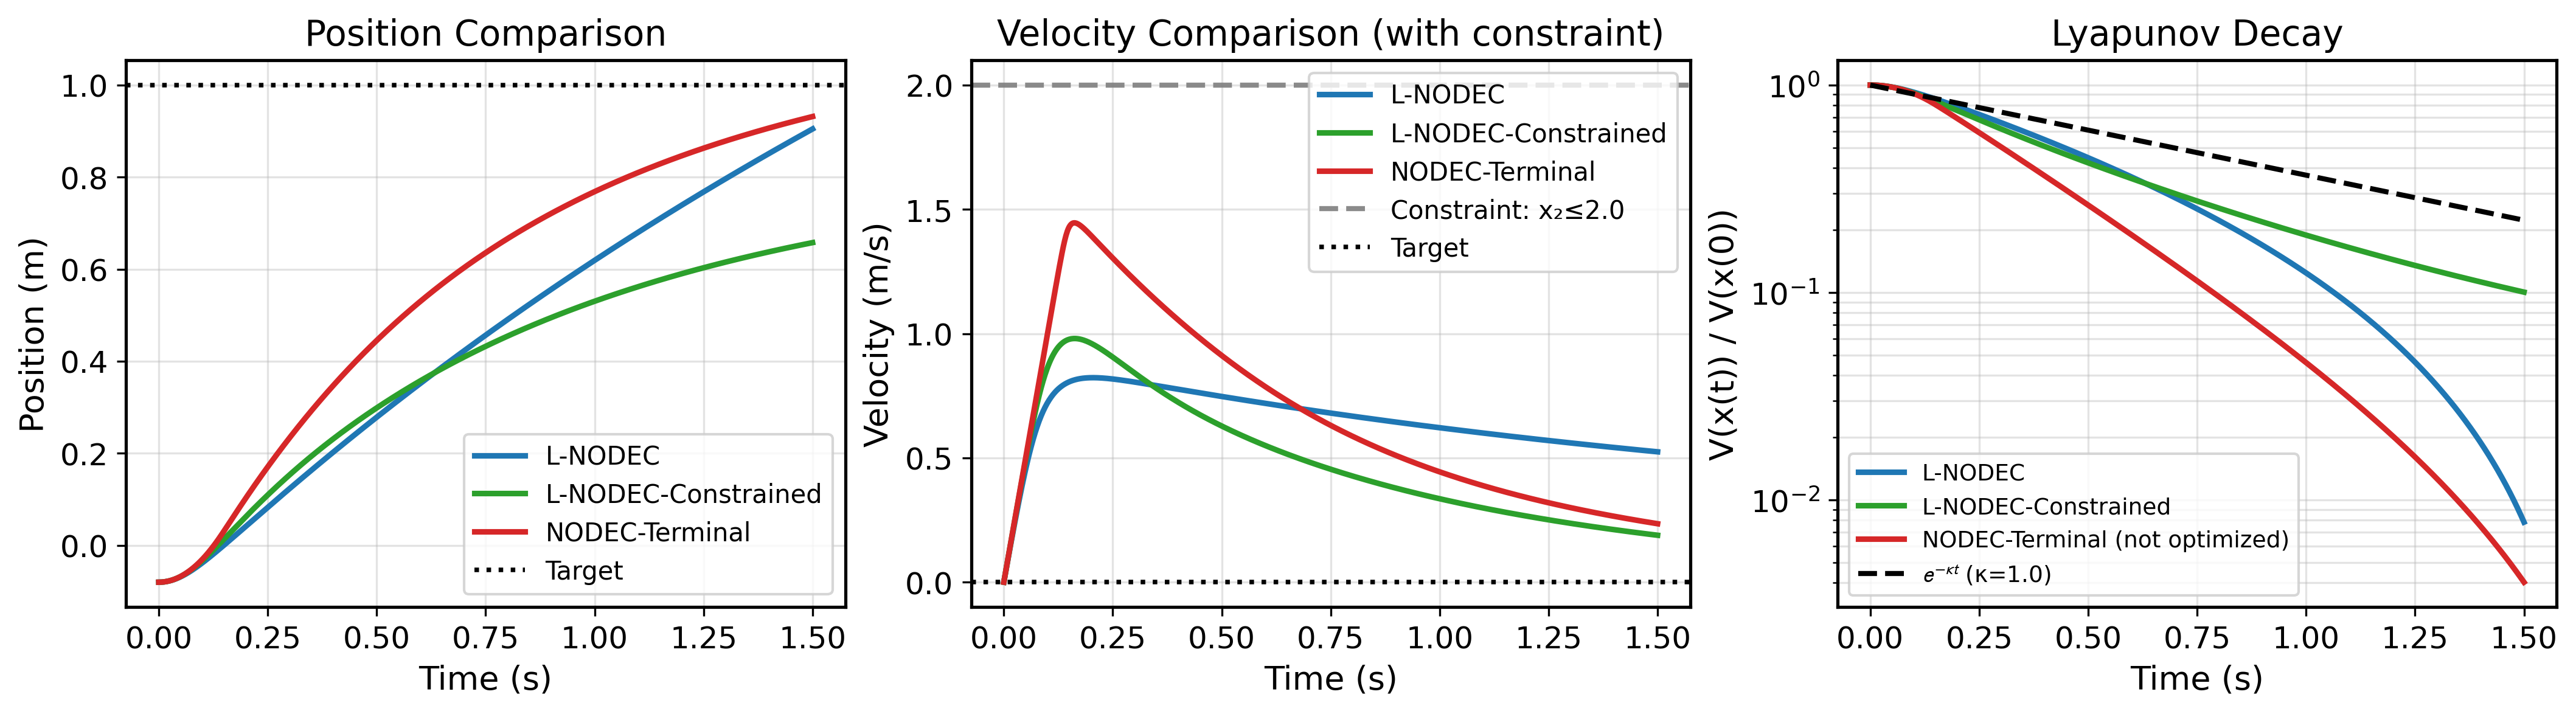

In [17]:
# (Optional) if you haven't already:
# set_plot_style()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)

# Method colors (tab10): blue, green, red
colors_methods = {
    'L-NODEC': 'C0',
    'L-NODEC-Constrained': 'C2',
    'NODEC-Terminal': 'C3',
}

trajectories_all = {
    'L-NODEC': traj_lnodec,
    'L-NODEC-Constrained': traj_constrained,
    'NODEC-Terminal': traj_terminal,
}

# --- Plot 1: Position ---
for method_name, traj in trajectories_all.items():
    axes[0].plot(time_grid_np, traj[:, 0],
                 color=colors_methods[method_name], linewidth=2.2, label=method_name)
axes[0].axhline(float(z_target[0]), color='black', linestyle=':', linewidth=1.8, label='Target')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('Position Comparison')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.35)

# --- Plot 2: Velocity (with constraint line) ---
for method_name, traj in trajectories_all.items():
    axes[1].plot(time_grid_np, traj[:, 1],
                 color=colors_methods[method_name], linewidth=2.2, label=method_name)
axes[1].axhline(x2_max, color='C7', linestyle='--', linewidth=2.0,
                label=f'Constraint: x₂≤{x2_max}', alpha=0.9)   # neutral-ish color to avoid confusion
axes[1].axhline(0, color='black', linestyle=':', linewidth=1.8, label='Target')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Velocity (m/s)')
axes[1].set_title('Velocity Comparison (with constraint)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.35)

# --- Plot 3: Lyapunov decay ---
eps = 1e-12
for method_name, traj in trajectories_all.items():
    V_traj = []
    for x in traj:
        x_torch = torch.tensor(x, dtype=torch.float32)
        V = lyapunov_fn.potential(x_torch, z_target).item()
        V_traj.append(V)
    V_traj = np.array(V_traj)
    V_norm = np.clip(V_traj / (V_traj[0] + eps), eps, None)  # log-safe
    label = method_name if 'L-NODEC' in method_name else f'{method_name} (not optimized)'
    axes[2].plot(time_grid_np, V_norm,
                 color=colors_methods[method_name], linewidth=2.2, label=label)

exp_bound = np.exp(-kappa * time_grid_np)
axes[2].plot(time_grid_np, exp_bound, 'k--', linewidth=2.0, label=fr'$e^{{-\kappa t}}$ (κ={kappa})')
axes[2].set_xlabel('Time (s)')
axes[2].set_ylabel('V(x(t)) / V(x(0))')
axes[2].set_title('Lyapunov Decay')
axes[2].set_yscale('log')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.35, which='both')

plt.show()


In [18]:
## Phase Portraits: All Methods Side-by-Side

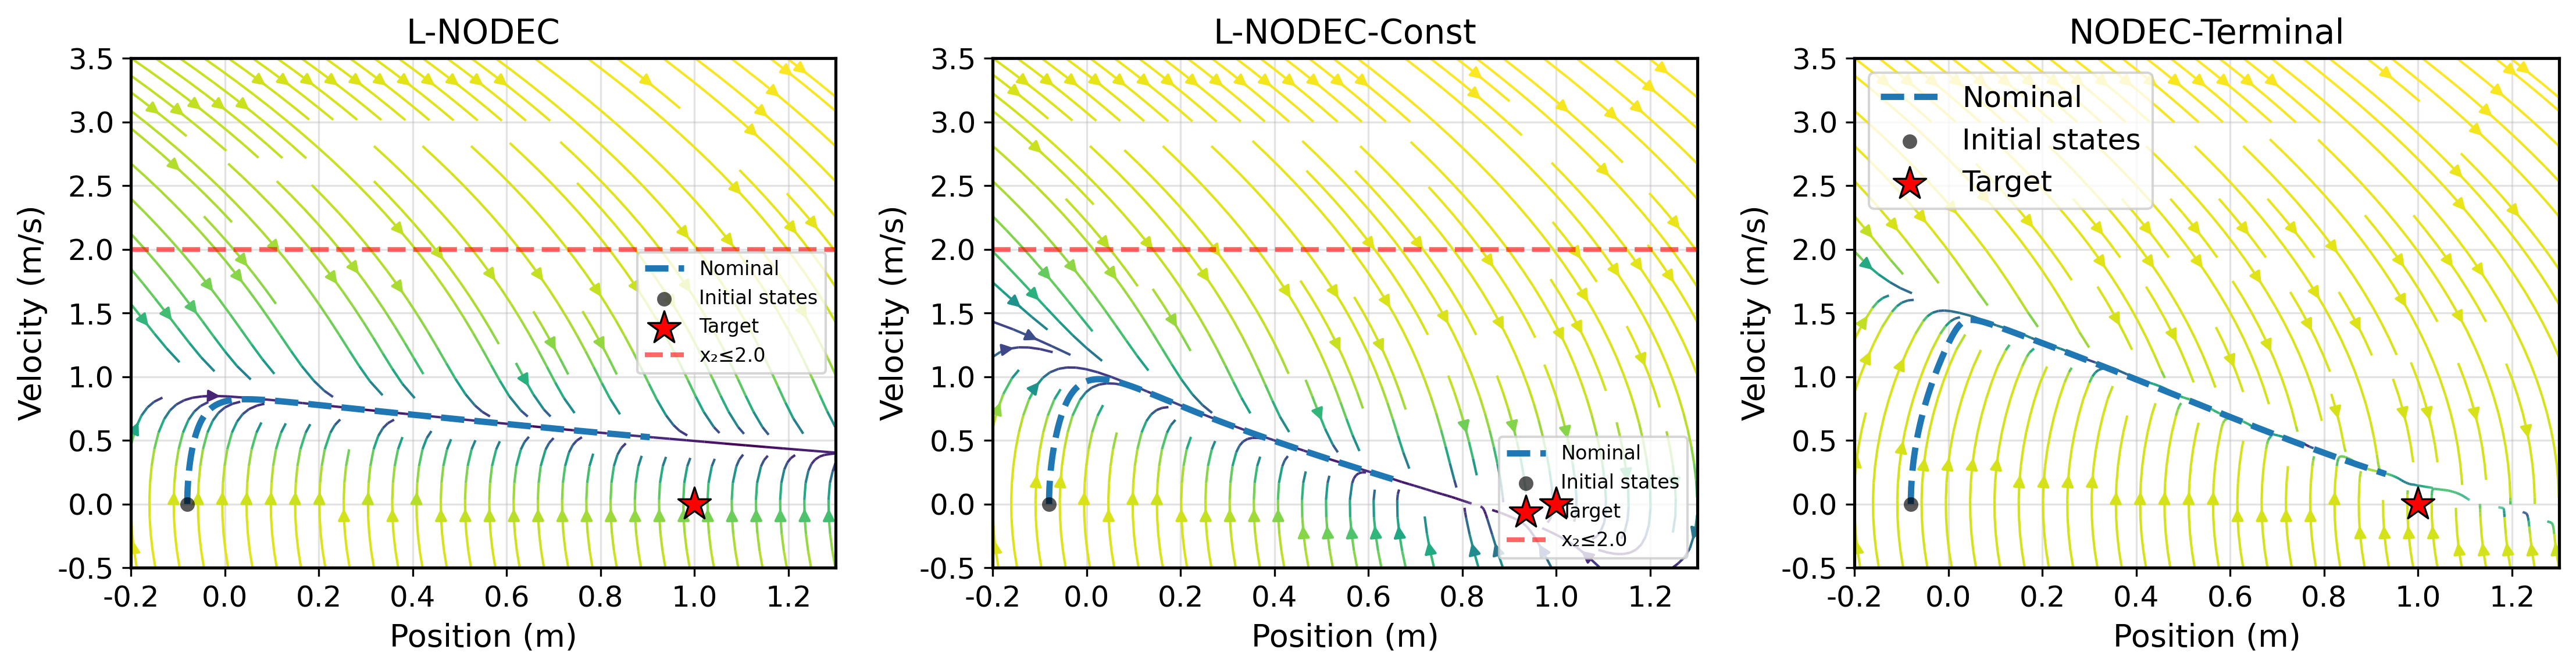

In [19]:
def compute_vector_field_for_policy(policy_to_use):
    """Helper to compute vector field for a specific policy"""
    def vf(X1, X2):
        U1 = np.zeros_like(X1)
        U2 = np.zeros_like(X2)
        for i in range(X1.shape[0]):
            for j in range(X1.shape[1]):
                x = torch.tensor([X1[i, j], X2[i, j]], dtype=dtype, device=device)
                with torch.no_grad():
                    u = policy_to_use(x)
                    xdot = double_integrator_dynamics(x, u, 0.0)
                U1[i, j] = xdot[0].item()
                U2[i, j] = xdot[1].item()
        return U1, U2
    return vf

# Create side-by-side phase portraits for all methods
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (method_name, policy_method, traj) in enumerate([
    ('L-NODEC', policy, traj_lnodec),
    ('L-NODEC-Const', policy_constrained, traj_constrained),
    ('NODEC-Terminal', policy_terminal, traj_terminal),
]):
    plot_phase_portrait(
        axes[idx],
        trajectories=[traj],
        initial_states=x0_test.cpu().numpy().reshape(1, -1),
        final_states=traj[-1].reshape(1, -1),
        target_state=target_state,
        vector_field_fn=compute_vector_field_for_policy(policy_method),
        title=f'{method_name}',
        x1_lim=(-0.2, 1.3),
        x2_lim=(-0.5, 3.5),
    )
    
    # Add constraint line on phase portrait
    if 'Const' in method_name or idx == 0:  # Show on constrained and first plot
        axes[idx].axhline(x2_max, color='red', linestyle='--', linewidth=2, 
                         alpha=0.6, label=f'x₂≤{x2_max}')
        axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Generate test ICs uniformly from [-0.1, 0.1] (same for all methods)
num_robustness_test = 20
x0_robustness_tests = [dataset_sampler_eval()[0] for _ in range(num_robustness_test)]

print(f"Evaluating all methods on {num_robustness_test} uniformly sampled ICs (±2σ)...\n")

# Evaluate all THREE methods on SAME test set
results_lnodec_rob = []
results_constrained_rob = []
results_terminal_rob = []

for x0 in x0_robustness_tests:
    results_lnodec_rob.append(trainer.evaluate(x0, z_target, time_grid, compute_stability_metrics=False))
    results_constrained_rob.append(trainer_constrained.evaluate(x0, z_target, time_grid, compute_stability_metrics=False))
    results_terminal_rob.append(trainer_terminal.evaluate(x0, z_target, time_grid))

# Extract all trajectories for each method
trajs_lnodec = [r['trajectory'].cpu().numpy() for r in results_lnodec_rob]
trajs_constrained = [r['trajectory'].cpu().numpy() for r in results_constrained_rob]
trajs_terminal = [r['trajectory'].cpu().numpy() for r in results_terminal_rob]

# Compute statistics
def compute_robustness_stats(results_list):
    final_dists = [r['final_distance'].item() for r in results_list]
    return {
        'mean': np.mean(final_dists),
        'std': np.std(final_dists),
        'min': np.min(final_dists),
        'max': np.max(final_dists),
    }

def compute_constraint_violations(results_list, x2_max):
    """Check how many trajectories violate x₂ ≤ x2_max"""
    violations = 0
    max_violations = []
    for r in results_list:
        traj = r['trajectory'].cpu().numpy()
        max_x2 = traj[:, 1].max()
        max_violations.append(max_x2)
        if max_x2 > x2_max:
            violations += 1
    return violations, np.array(max_violations)

stats_lnodec_rob = compute_robustness_stats(results_lnodec_rob)
stats_constrained_rob = compute_robustness_stats(results_constrained_rob)
stats_terminal_rob = compute_robustness_stats(results_terminal_rob)

viol_lnodec, max_x2_lnodec = compute_constraint_violations(results_lnodec_rob, x2_max)
viol_constrained, max_x2_constrained = compute_constraint_violations(results_constrained_rob, x2_max)
viol_terminal, max_x2_terminal = compute_constraint_violations(results_terminal_rob, x2_max)

print("="*80)
print("Robustness Test: Final Distance to Target (±2σ edge cases)")
print("="*80)
print(f"Training: Normal(μ=0, σ=0.05)")
print(f"Testing:  Uniform([-0.1, 0.1]) - tests rarely-seen edge cases")
print("-"*80)
print(f"{'Method':<20} {'Mean':<12} {'Std':<12} {'Min':<12} {'Max':<12}")
print("-"*80)
print(f"{'L-NODEC':<20} {stats_lnodec_rob['mean']:<12.4f} {stats_lnodec_rob['std']:<12.4f} {stats_lnodec_rob['min']:<12.4f} {stats_lnodec_rob['max']:<12.4f}")
print(f"{'L-NODEC-Const':<20} {stats_constrained_rob['mean']:<12.4f} {stats_constrained_rob['std']:<12.4f} {stats_constrained_rob['min']:<12.4f} {stats_constrained_rob['max']:<12.4f}")
print(f"{'NODEC-Terminal':<20} {stats_terminal_rob['mean']:<12.4f} {stats_terminal_rob['std']:<12.4f} {stats_terminal_rob['min']:<12.4f} {stats_terminal_rob['max']:<12.4f}")
print("="*80)

print(f"\nConstraint Violations (x₂ > {x2_max} m/s):")
print(f"{'Method':<20} {'Violations':<15} {'Max x₂ (mean)':<15} {'Max x₂ (max)':<15}")
print("-"*80)
print(f"{'L-NODEC':<20} {viol_lnodec}/{num_robustness_test:<10} {max_x2_lnodec.mean():<15.3f} {max_x2_lnodec.max():<15.3f}")
print(f"{'L-NODEC-Const':<20} {viol_constrained}/{num_robustness_test:<10} {max_x2_constrained.mean():<15.3f} {max_x2_constrained.max():<15.3f}")
print(f"{'NODEC-Terminal':<20} {viol_terminal}/{num_robustness_test:<10} {max_x2_terminal.mean():<15.3f} {max_x2_terminal.max():<15.3f}")
print("="*80)


In [ ]:
# (Optional) if you haven't already:
# set_plot_style()

from visualization import plot_multi_method_comparison

# TOGGLE: Set to True to show all trajectories, False for mean±std
SHOW_ALL_TRAJECTORIES = True

# Choose tab10 colors per method
colors_methods = {
    'L-NODEC': 'C0',         # blue
    'L-NODEC-Const': 'C2',   # green
    'NODEC-Terminal': 'C3',  # red
}

# Prepare data for comparison plot
methods_data = {
    'L-NODEC': {
        'trajectories': trajs_lnodec,
        'color': colors_methods['L-NODEC'],
    },
    'L-NODEC-Const': {
        'trajectories': trajs_constrained,
        'color': colors_methods['L-NODEC-Const'],
    },
    'NODEC-Terminal': {
        'trajectories': trajs_terminal,
        'color': colors_methods['NODEC-Terminal'],
    },
}

print(f"Plotting {'all 20 trajectories' if SHOW_ALL_TRAJECTORIES else 'mean ± std'} for each method...")

fig = plot_multi_method_comparison(
    time_grid=time_grid_np,
    methods_data=methods_data,
    target_state=target_state,
    lyapunov_fn=lyapunov_fn,
    kappa=kappa,
    x2_max=x2_max,
    show_all_trajectories=SHOW_ALL_TRAJECTORIES,
    figsize=(14, 3.8),  # more compact default
)

plt.show()

print("\n✓ Comparison plot complete!")
print(f"  Mode: {'All trajectories (20 per method)' if SHOW_ALL_TRAJECTORIES else 'Mean ± std envelope'}")
print("  Change SHOW_ALL_TRAJECTORIES = False to see mean±std instead")


## **Comparison Plots: Position, Velocity, Lyapunov (All 20 Trajectories)**

In [ ]:
def compute_vector_field_for_policy(policy_to_use):
    """Helper to compute vector field for a specific policy"""
    def vf(X1, X2):
        U1 = np.zeros_like(X1)
        U2 = np.zeros_like(X2)
        for i in range(X1.shape[0]):
            for j in range(X1.shape[1]):
                x = torch.tensor([X1[i, j], X2[i, j]], dtype=dtype, device=device)
                with torch.no_grad():
                    u = policy_to_use(x)
                    xdot = double_integrator_dynamics(x, u, 0.0)
                U1[i, j] = xdot[0].item()
                U2[i, j] = xdot[1].item()
        return U1, U2
    return vf

# Create side-by-side phase portraits for all methods with ALL 20 trajectories
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Extract initial/final states from robustness test
initial_states_rob = np.array([x0.cpu().numpy() for x0 in x0_robustness_tests])
final_states_lnodec = np.array([t[-1] for t in trajs_lnodec])
final_states_constrained = np.array([t[-1] for t in trajs_constrained])
final_states_terminal = np.array([t[-1] for t in trajs_terminal])

methods_plot_data = [
    ('L-NODEC', policy, trajs_lnodec, final_states_lnodec),
    ('L-NODEC-Const', policy_constrained, trajs_constrained, final_states_constrained),
    ('NODEC-Terminal', policy_terminal, trajs_terminal, final_states_terminal),
]

for idx, (method_name, policy_method, trajs, final_states) in enumerate(methods_plot_data):
    plot_phase_portrait(
        axes[idx],
        trajectories=trajs,  # ALL 20 trajectories!
        initial_states=initial_states_rob,
        final_states=final_states,
        target_state=target_state,
        vector_field_fn=compute_vector_field_for_policy(policy_method),
        title=f'{method_name}',
        x1_lim=(-0.2, 1.3),
        x2_lim=(-0.5, 3.5),
    )
    
    # Add constraint line on all phase portraits
    axes[idx].axhline(x2_max, color='red', linestyle='--', linewidth=2, 
                     alpha=0.6, label=f'x₂≤{x2_max}')
    axes[idx].legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

print(f"✓ Phase portraits complete - showing all {num_robustness_test} trajectories per method!")

## **Phase Portraits: All Methods Side-by-Side (All 20 Trajectories)**


Toggle between showing all trajectories vs mean±std

## Summary Statistics

In [ ]:
final_distances = np.array([np.linalg.norm(fs - target_state) for fs in final_states])
V_decay_ratios = np.array([V_traj[-1] / V_traj[0] for V_traj in V_trajectories])

print("="*60)
print("Summary Statistics (Adversarial Trajectories)")
print("="*60)
print(f"Number of trajectories: {num_adversarial}")
print(f"\nFinal distance to target:")
print(f"  Mean:   {final_distances.mean():.4f} m")
print(f"  Std:    {final_distances.std():.4f} m")
print(f"  Min:    {final_distances.min():.4f} m")
print(f"  Max:    {final_distances.max():.4f} m")
print(f"\nV(x_final) / V(x_0):")
print(f"  Mean:   {V_decay_ratios.mean():.4e}")
print(f"  Std:    {V_decay_ratios.std():.4e}")
print(f"  Target: {np.exp(-kappa * t_final):.4e} (e^(-κT))")
print("="*60)

In [ ]:
final_distances = np.array([np.linalg.norm(fs - target_state) for fs in final_states])
V_decay_ratios = np.array([V_traj[-1] / V_traj[0] for V_traj in V_trajectories])

print("="*60)
print("L-NODEC Robustness Test Results (±2σ edge cases)")
print("="*60)
print(f"Number of test trajectories: {num_adversarial}")
print(f"Test distribution: Uniform([-0.1, 0.1]) (±2σ from training)")
print(f"Training distribution: Normal(μ=0, σ=0.05)")
print(f"\nFinal distance to target:")
print(f"  Mean:   {final_distances.mean():.4f} m")
print(f"  Std:    {final_distances.std():.4f} m")
print(f"  Min:    {final_distances.min():.4f} m")
print(f"  Max:    {final_distances.max():.4f} m")
print(f"\nV(x_final) / V(x_0):")
print(f"  Mean:   {V_decay_ratios.mean():.4e}")
print(f"  Std:    {V_decay_ratios.std():.4e}")
print(f"  Target: {np.exp(-kappa * t_final):.4e} (e^(-κT))")
print("="*60)